## 用于画图,可视化训练效果

In [1]:
import sys
import torch
from agent.PPO import PPO
from env.AdaptiveOpticsEnv import AOEnv
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import argparse



     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304

 25%|██▌       | 1/4 [00:01<00:05,  1.83s/it]

100/357
Time elapsed: 1.8258616924285889 s


 50%|█████     | 2/4 [00:03<00:03,  1.77s/it]

200/357
Time elapsed: 1.7344412803649902 s


 75%|███████▌  | 3/4 [00:05<00:01,  1.73s/it]

300/357
Time elapsed: 1.6790311336517334 s


100%|██████████| 4/4 [00:06<00:00,  1.54s/it]

400/357
Time elapsed: 0.932891845703125 s


No Modal Gains found. All gains set to 1
-> Computing the initial phase screen...
initial phase screen : 0.0065610408782958984 s
ZZt.. : 1.3751146793365479 s
ZXt.. : 0.18456363677978516 s
XXt.. : 0.09825706481933594 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.005976438522338867 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.6689300537109375e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.0058324337005615234 s
ZZt.. : 2.384185791015625e-07 s
ZXt.. : 1.4543533325195312e-05 s
XXt.. : 6.198883056640625e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
WARNING !!!! THE LIGHT IN THE SUBAPERTURE IS MAYBE WRAPPING !!!5.3 % of the total flux detected on the edges of the subapertures. 

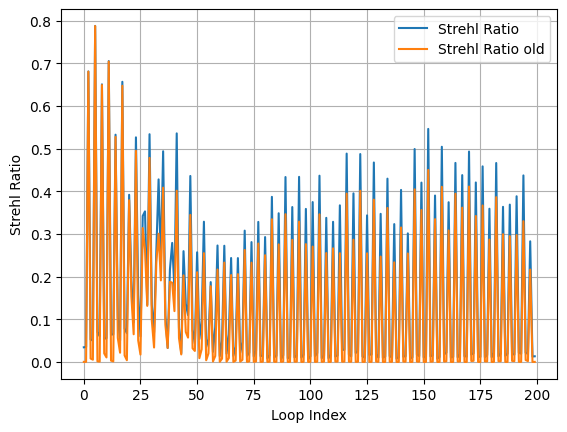

episode_return= -21.421509189566343


In [ ]:

env = AOEnv()
state, _ = env.reset()
episode_return = 0
done = False
action = [0.6,1000,1,1000]
while not done:
    state, reward, done, _, info = env.step(action)
    episode_return += reward
plt.figure()
plt.plot(np.arange(env.max_step), env.SR, label='Strehl Ratio')
plt.plot(np.arange(env.max_step), env.SR_old, label='Strehl Ratio old')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.legend()
plt.grid()
plt.show()

print('episode_return=',episode_return)

Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304

Iteration 0:   0%|          | 0/20 [00:00<?, ?it/s]

-> Computing the initial phase screen...
initial phase screen : 0.008632898330688477 s
ZZt.. : 1.8632347583770752 s
ZXt.. : 0.173142671585083 s
XXt.. : 0.09072709083557129 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.0060536861419677734 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 1.4066696166992188e-05 s
XXt.. : 5.7220458984375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.0058863162994384766 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.33514404296875e-05 s
XXt.. : 5.4836273193359375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!


Iteration 9: 100%|██████████| 20/20 [03:18<00:00,  9.92s/it, episode=191, return=68.9]


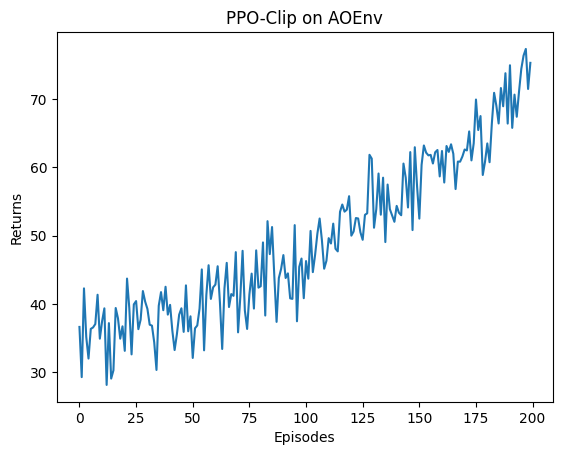

In [ ]:
env_name = 'AOEnv'
env = AOEnv()
actor_lr = 1e-4
critic_lr = 5e-3
gamma = 0.9
lamda = 0.9
epsilon = 0.2
epochs = 10
episodes = 200
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
hidden_dim = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lamda, epochs, epsilon, gamma, device)
return_list = []
for i in range(10):
    with tqdm(total=int(episodes/10), desc="Iteration %d" % i) as pbar:
        for episode in range(int(episodes/10)):
            state, _ = env.reset(seed=0)
            done = False
            transition_dict = {
                "states": [],
                "actions": [],
                "rewards": [],
                "next_states": [],
                "dones": []
            }
            episode_return = 0
            while not done:
                action = agent.take_action(state)
                next_state,  reward,  d1, d2, _ = env.step(action)
                done = d1 or d2
                transition_dict["states"].append(state)
                transition_dict["actions"].append(action)
                transition_dict["rewards"].append(reward)
                transition_dict["next_states"].append(next_state)
                transition_dict["dones"].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            agent.update(transition_dict)
            if episode % 10 == 0 and len(return_list) >= 10:
                pbar.set_postfix({'episode': '%d' % (episodes / 10 * i + episode + 1),
                                'return': np.mean(return_list[-10:])
                                })
            pbar.update(1)


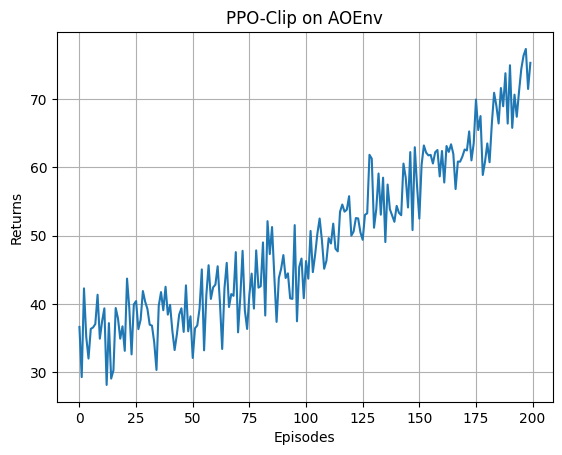

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO-Clip on {}'.format(env_name))
plt.grid()
plt.show()

### 用训练的agent跑一回合的SR变化和return

Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304

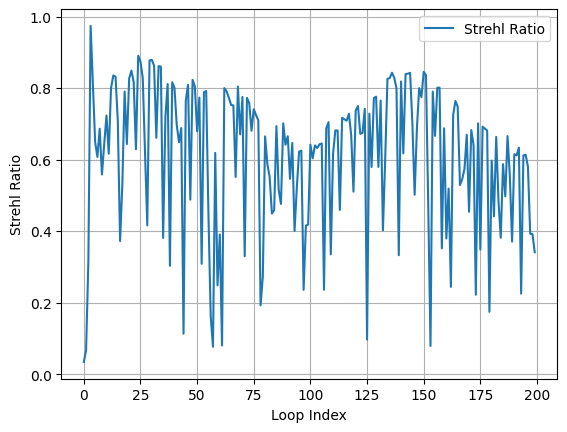

episode_return_agent= 77.0848479635154


In [7]:
env = AOEnv()
state, _ = env.reset()
episode_return_agent = 0
done = False
while not done:
    action = agent.take_action(state)
    next_state, reward, done, _, info = env.step(action)
    state = next_state
    episode_return_agent += reward
plt.figure()
plt.plot(np.arange(env.max_step), env.SR, label='Strehl Ratio')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.legend()
plt.grid()
plt.show()

print('episode_return_agent=',episode_return_agent)